In [1]:
# ============================================================
# 0. IMPORTS
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline

sns.set(style="whitegrid")
np.random.seed(42)

In [2]:
# ============================================================
# 1. LOAD DATA
# ============================================================
print("Loading MNIST...")
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data.values.astype(np.float32)
y = mnist.target.astype(int)

print("Dataset shape:", X.shape)

Loading MNIST...
Dataset shape: (70000, 784)


In [3]:
# ============================================================
# 2. TRAIN-TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [4]:
# ============================================================
# 3. STANDARDIZATION
# ============================================================
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)


Performing PCA...

Variance Summary:
PC1 explains: 0.0564
First 5 PCs explain: 0.1885
Components for 80% variance: 149
Components for 90% variance: 237
Components for 95% variance: 330


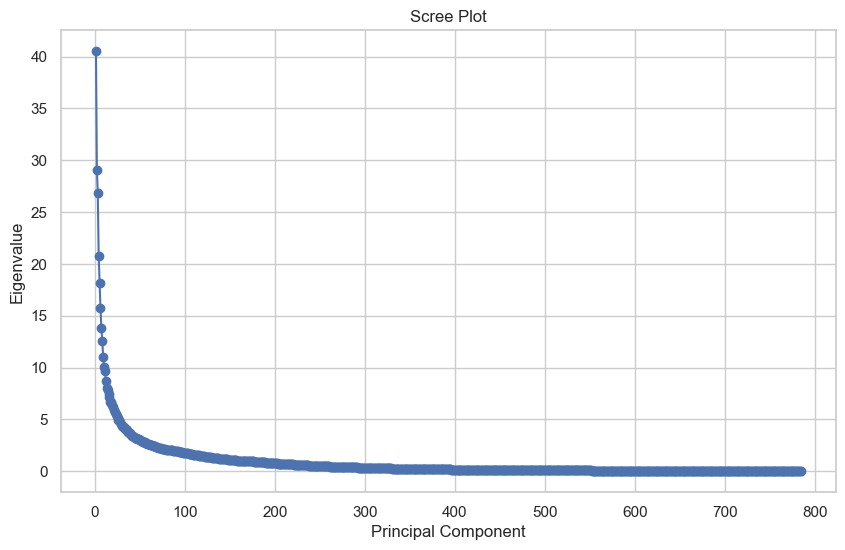

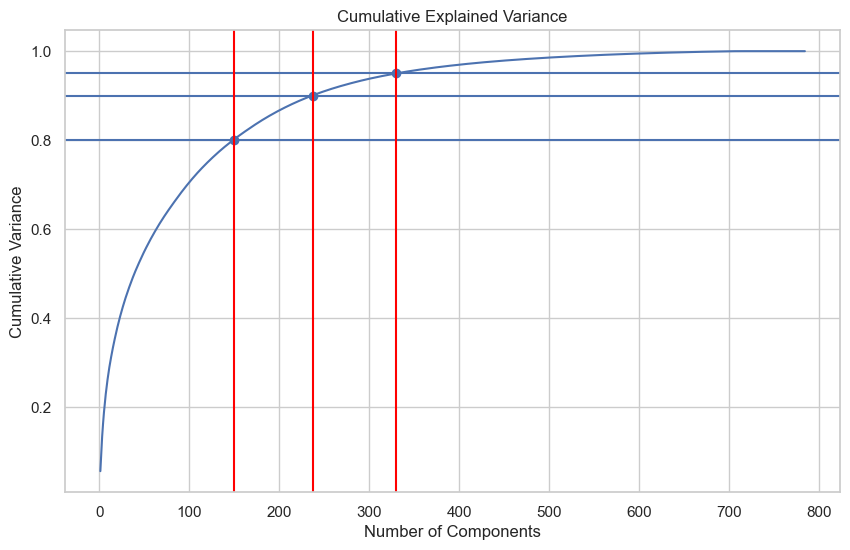

In [5]:
# ============================================================
# 4. PCA ANALYSIS
# ============================================================

print("\nPerforming PCA...")

pca_full = PCA(n_components=784)
pca_full.fit(X_train_std)

eigenvalues = pca_full.explained_variance_
explained_ratio = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_ratio)

components = np.arange(1, len(eigenvalues) + 1)

# ------------------------------------------------
# Find component counts for key variance levels
# ------------------------------------------------
comp_80 = np.argmax(cum_var >= 0.80) + 1
comp_90 = np.argmax(cum_var >= 0.90) + 1
comp_95 = np.argmax(cum_var >= 0.95) + 1

print("\nVariance Summary:")
print(f"PC1 explains: {explained_ratio[0]:.4f}")
print(f"First 5 PCs explain: {cum_var[4]:.4f}")
print(f"Components for 80% variance: {comp_80}")
print(f"Components for 90% variance: {comp_90}")
print(f"Components for 95% variance: {comp_95}")

# ------------------------------------------------
# Scree Plot (first 100 for clarity)
# ------------------------------------------------
plt.figure(figsize=(10,6))
plt.plot(components, eigenvalues, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.grid(True)
plt.show()

# ------------------------------------------------
# Cumulative Variance Plot with Markers
# ------------------------------------------------
plt.figure(figsize=(10,6))
plt.plot(components, cum_var)

plt.axhline(0.80)
plt.axhline(0.90)
plt.axhline(0.95)

plt.axvline(comp_80, color = "red")
plt.axvline(comp_90, color = "red")
plt.axvline(comp_95, color = "red")

plt.scatter([comp_80, comp_90, comp_95],
            [0.80, 0.90, 0.95])

plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.grid(True)
plt.show()

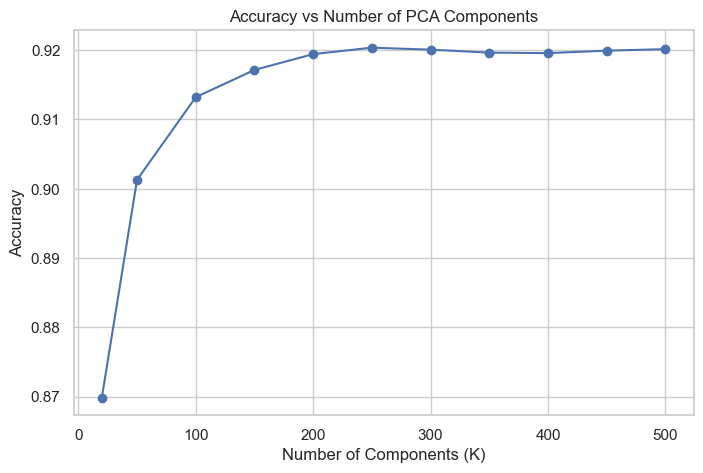

In [7]:
# ============================================================
# ACCURACY vs K ANALYSIS (Optimized Version)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Define K values
K_values = [20, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]

# Ensure K does not exceed allowed limit
max_k = min(X_train_std.shape)
K_values = [k for k in K_values if k <= max_k]

# Precompute PCA once (FAST 🚀)
pca = PCA(n_components=max(K_values))
T_train_full = pca.fit_transform(X_train_std)
T_test_full = pca.transform(X_test_std)

acc_list = []

# Loop over K values
for K in K_values:
    T_train = T_train_full[:, :K]
    T_test = T_test_full[:, :K]

    clf = LogisticRegression(max_iter=2000)
    clf.fit(T_train, y_train)

    pred = clf.predict(T_test)
    acc = accuracy_score(y_test, pred)
    acc_list.append(acc)

# Plot results
plt.figure(figsize=(8,5))
plt.plot(K_values, acc_list, marker='o')
plt.grid(True)
plt.title("Accuracy vs Number of PCA Components")
plt.xlabel("Number of Components (K)")
plt.ylabel("Accuracy")
plt.show()

In [8]:
# ============================================================
# 6. SELECT K
# ============================================================
K = 250
pca_k = PCA(n_components=K)

T_train = pca_k.fit_transform(X_train_std)
T_test = pca_k.transform(X_test_std)

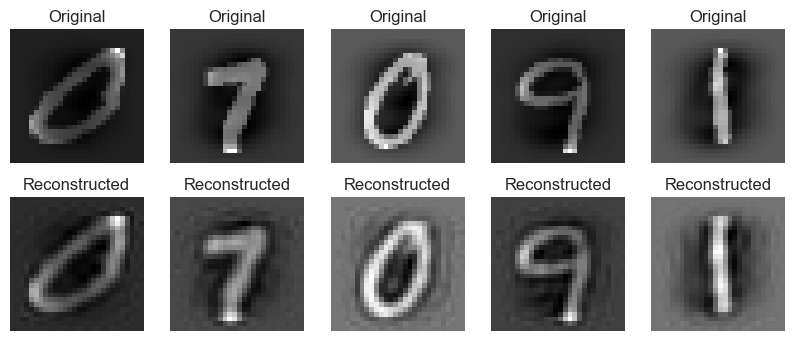

In [9]:
# ============================================================
# 7. RECONSTRUCTION VISUALIZATION
# ============================================================
X_train_recon = pca_k.inverse_transform(T_train)

plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train_std[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    plt.subplot(2,5,i+6)
    plt.imshow(X_train_recon[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()

In [10]:
# ============================================================
# 8. RESIDUAL ANALYSIS
# ============================================================
R_train = X_train_std - X_train_recon
R_test = X_test_std - pca_k.inverse_transform(T_test)

Q_train = np.sum(R_train**2, axis=1)
Q_test = np.sum(R_test**2, axis=1)

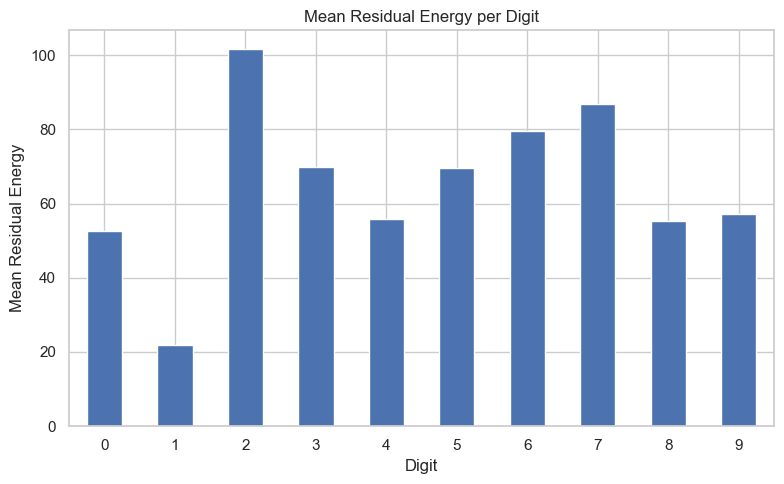

In [11]:
# ============================================================
# 9. RESIDUAL ENERGY PER DIGIT
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Digit-wise Residual Energy
df = pd.DataFrame({"digit": y_train, "Q": Q_train})
mean_Q = df.groupby("digit")["Q"].mean()

plt.figure(figsize=(8,5))

mean_Q.plot(kind="bar")

plt.title("Mean Residual Energy per Digit")
plt.xlabel("Digit")
plt.ylabel("Mean Residual Energy")

plt.xticks(rotation=0)   # ← makes labels straight
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# 10. RESIDUAL PCA
# ============================================================
K2 = 100
pca_res = PCA(n_components=K2)

TR_train = pca_res.fit_transform(R_train)
TR_test = pca_res.transform(R_test)

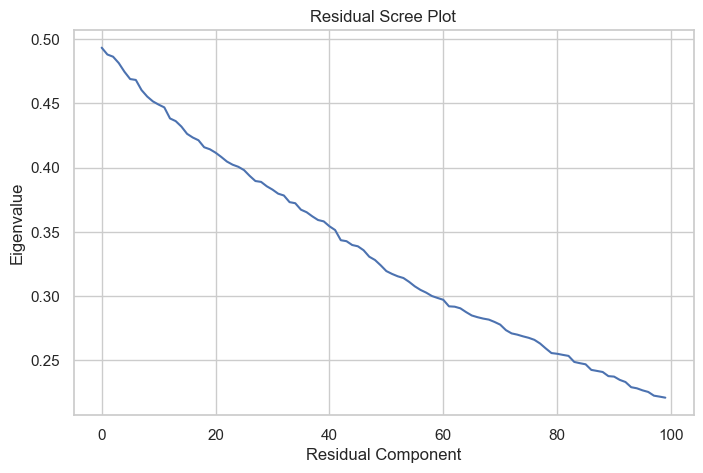

In [13]:
# ============================================================
# 11. RESIDUAL SCREE PLOT
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(pca_res.explained_variance_)
plt.title("Residual Scree Plot")
plt.xlabel("Residual Component")
plt.ylabel("Eigenvalue")
plt.show()

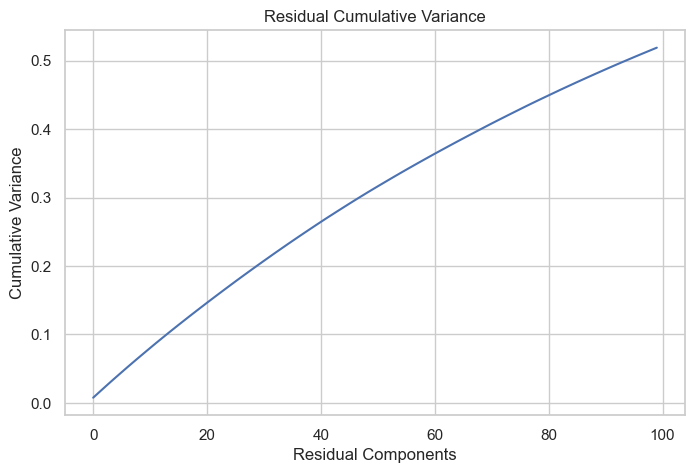

In [14]:
# ============================================================
# 12. RESIDUAL CUMULATIVE VARIANCE
# ============================================================
plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca_res.explained_variance_ratio_))
plt.title("Residual Cumulative Variance")
plt.xlabel("Residual Components")
plt.ylabel("Cumulative Variance")
plt.show()